<a href="https://colab.research.google.com/github/fhzhkunming/ST-554-HW5/blob/main/HW5_Hui.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ST 554 HW#5

Hui Fang

2/28/2026

# Part I - Concepts (11 pts)

 1. We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big data or a topic you are interested in where big data would arise. Specifically address the five V’s for the example and whether/how they apply to your example. (5 pts)

    A: Big Data refers to datasets that are too large, fast-moving, or complex to be handled normally. The five V's of Big Data refer to:
    - **Volume**: massive amounts of data
    - **Velocity**: data generated and processed at high speed
    - **Variety**: many formats of data, such as structred tables, text, images, videos, etc
    - **Veracity**: data quality and reliabbility vary
    - **Value**: it's costly to generated the data and the insights gained must be meaningful

    One example of big data in my experience is genome-wide association studies (GWAS) in cotton plants. We grew many cotton varieties across multiple locations and years, generating large **volume** of phenotypic data from measurements, images, and videos on yield, fiber quality, and environmental factors. These datasets included many **varieties** of data, from structured trait tables to unstructured imaging and videos files, and their **veracity** varies because field measurements and environmental conditions introduced noise. DNA sequencing added even more **volume** and was produced at high **velocity** by next generation seqencing platforms. Althogh collecting and processing these data was expensive, the biological and breeding **value** was substantial: we identified genetic factors underling key traits, which can guide improvements through gene editing or conventional breeding.

2. Read about the database we'll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database. (3 pts)

    A: The CRUD acronym refers to **C**reate data, **R**ead data, **U**pdate data, and **D**elete data.

    In the database we used in partIV:

    **C**(**C**reate): means adding new rows or tables to the databse. We didn't create new tables or rows in the `Lahman`database bescause it is read-only. But an example would be: `INSERT INTO Teams (teamID, yearID, name) VALUES ('XYZ', 2025, 'Example Team');`.

    **R**(**R**ead): means querying data from the database. We used the `pd.read_sql()` to read tables, such as selecting all teams that played in the year 2015: `pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", con)`.

    **U**(**U**pdate): means modifying existing data in the database. We did not update the `Lahman` database itself, but we created new variables in pandas (e.g., win/loss percentage), which updates the DataFrame but not the database. We could update the database through something like: `UPDATE Teams SET W = 100 WHERE teamID = 'PIT' AND yearID = 2015;`.

    **D**(**D**elete): means removing rows or tables from the database. We didn't delete any data from the `Lahman` database, but an example would be: `DELETE FROM Teams WHERE yearID = 1900;`.

3. What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.) (3 pts)

    A: The `HAVING` clause is used to filter groups created by the `GROUP BY` clause. While `WHERE` clause filters individual rows before grouping, the `HAVING` clause filters aggregated results after grouping. The `GROUP BY` clause groups rows into summary groups, and `HAVING` applies conditions to those groups, typically using aggregate functions such as `COUNT`, `SUM`, or `AVG`. Although commonly paired with `GROUP BY`, SQLite also allows `HAVING` without it, in which case the entire result is treated as a single group.

# Part II - Simulation of a Sampling Distribution (20 pts)



4. We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We'll now look at the sampling distribution of the sample slope from an SLR model using simulation.
- Recall we assume the following model for SLR:
$$ Y_i = \beta_0 + \beta_1 x_i + E_i $$
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance $σ^2$. Let's assume $σ^2 = 1$ for simplicity.
- We can generate data from this model by assuming values for $β_0$, $β_1$, and *n*, along with a sequence of *x* values via the following code:

```
# import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
# create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()
```

- Now we can use sklearn to obtain the estimate for the slope (and save that value) as we did earlier in the course.

- Repeat the above process 5000 times. To be specific: (11 pts)

    – Generate the y values using the code with rng.standard_normal()

    – Find the ‘best’ slope via sklearn

    – Save that slope in some object

- We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Create a histogram of the sample slope values you found. (3 pts)

In [1]:
# import some modules needed
import pandas as pd
from sklearn import linear_model
import sklearn.metrics as metrics
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt

# define a function to calculate RMSE
def rmse(y,pres):
    return np.sqrt(metrics.mean_squared_error(y, pred))

# set up random number generator seed, beta_0, and beta_1
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)                                         # define sample size

reg = linear_model.LinearRegression()              # create a reg object
slopes = []                                        # create an object to store slope estimates
rmse_values = []                                   # create an object to store RMSE values

# loop to fit the SLR model to calculate slopes and RMSEs
for i in range(5000):
    y = beta_0 + beta_1*x + rng.standard_normal(n) # generate new y each iteration
    reg.fit(x.reshape(-1, 1), y)                   # fit the model
    slopes.append(reg.coef_[0])                    # save the slope estimates
    pred = reg.predict(x.reshape(-1, 1))           # make predictions
    rmse_values.append(rmse(y, pred))              # save the RMSE

# find the best slope
best_index = np.argmin(rmse_values)                # finds the index of the smallest RMSE
best_slope = slopes[best_index]                    # find the best slop associated with smallest RMSE
best_rmse = rmse_values[best_index]                # find the smallest rmse
print(best_slope, best_rmse)                       # print best slop and smalles rmse

1.4802726640385528 0.5788478455698538


So, the "best" slope is 1.4802 and stored in best_slop object.

- plot the slopes via a histogram

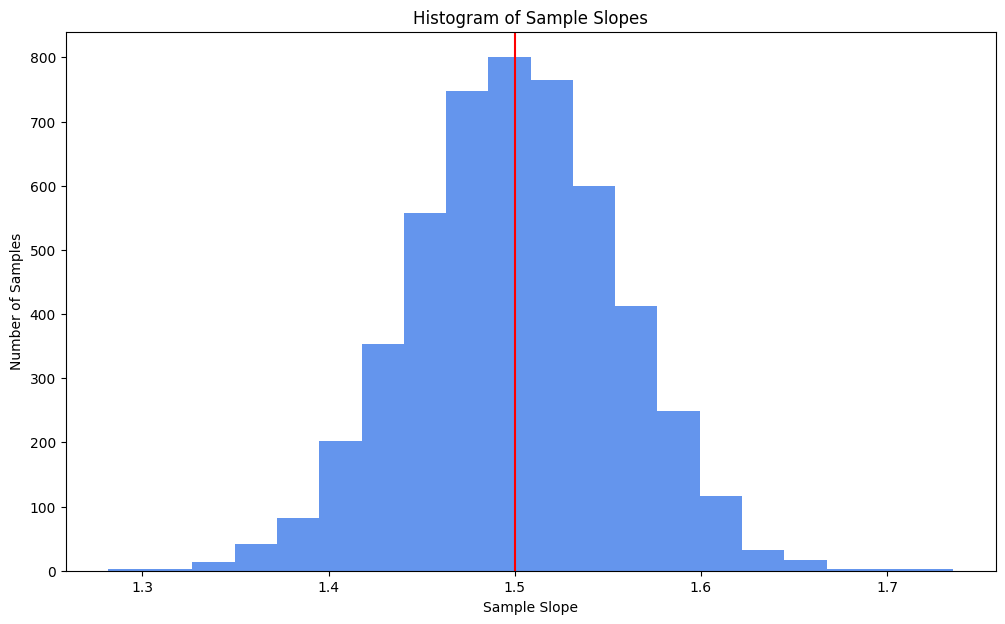

In [3]:
plt.figure(figsize = (12, 7))                           # define figure size
plt.hist(slopes, bins = 20, color = "cornflowerblue")   # set histogram arguments
plt.title("Histogram of Sample Slopes")                 # define the plot title
plt.ylabel("Number of Samples")                         # label x-axis
plt.xlabel("Sample Slope")                              # label y-axis
plt.axvline(x = 1.5, c = "Red")                         # show the 'true' slope
plt.show()                                              # show the histogram

- Use your sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65. (3 pts)
- Give an interpretation of this value and why it might be important for us in relation to a hypothesis test. (3 pts)

In [7]:
slopes = np.array(slopes)                          # convert the slope values to a ap.array
probability = np.sum(slopes > 1.65)/len(slopes)    # compute the probability
print(probability)                                 # print out the calculated probability

0.0038


The probability of observing a sample slope larger than 1.65 is approximately 0.0038. This means that if the true slope is 1.5, only about 0.38% of random samples would produce a slope as large as 1.65.

In the context of hypothesis testing, this probability represents how extreme a slope of 1.65 would be under the null hypothesis. Because this probability is very small, a slope of 1.65 would be considered strong evidence against the null hypothesis that the true slope is 1.5.

# Part III - Big Data Examples & Rare Events (14 pts)

5. Consider [this article](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913) about bias in machine learning models

- Pick an example in the article and briefly outline the issue around the data used to fit the model.(3 pts)

    A: The article describes Amazon's resume-screening system as an example of implicit bias in machine learning. The algorithm was trained on data that already contained gender-biased patterns, which caused it to penalize resumes that included terms such as “women's chess club captain.” Because the training data reflected implicit biases against female applicants, the model reproduced and amplified those biases in its predictions.

- Describe how we might augment the data or otherwise account for the bias in that situation. (3 pts)

    A: To reduce the bias in this situation, the training data would need to be cleaned so the model no longer learns gender skewed patterns. This can be done by removing gender related terms, balancing the dataset so résumés linked to women are not treated as negative examples, and auditing the data for biased correlations. Simple safeguards such as debiasing techniques and periodic human review help ensure the model does not relearn or reinforce gender based discrimination.

6. Consider [this article](https://www.science.org/doi/10.1126/science.adh9607) about big data usage in the Earth Sciences
- Choose one of the three major areas the paper discusses. Summarize the use of big data there. Are there any biases or other missing data that might affect results? (I know this is likely difficult as most of us aren't experts in Earth science - just do your best - my goal is to try to get us to always ask questions about the data collected and used for a study!) (5 pts)

    A: In atmospheric science, big data is used to improve our understanding of climate processes, severe weather, and long term environmental change. The article explains that high resolution global climate models and massive observational and satellite datasets allow scientists to study ocean–atmosphere interactions, mid latitude storm tracks, wind resources, and biogeochemical processes like CO<sub>2</sub> exchange with atmosphere and oxygen levels at 150 m ocean depth. These large, diverse datasets also help identify potential abrupt climate "tipping points" that may be irreversible.

    Even with these advances, results can still be affected by data gaps and biases. Observations are uneven across regions and time periods, such as less sensor in deep ocean and underdeveloped regions, sensors accuracy varies, and climate models rely on assumptions that can introduce structural bias. Because the climate system is highly complex and interconnected, missing or biased data can influence predictions about storms, carbon exchange, or the likelihood of abrupt climate shifts.


7. Read through this short article: [Article](https://allendowney.substack.com/p/superbolts?utm_source=substack&utm_medium=email)

- Mostly I just want you to read this article to understand some ways in which rare events, and statisticians, play a role in different places. To have something to put here, can you think of another variable or scenario where understanding rare events is important? (3 pts)

    A: Rare events matter in many real‑world situations, and statisticians play a key role in understanding them. One example is rare diseases, which occur infrequently in the population but can have severe consequences for an individual or family when they do happen. Even though the probability of any one person developing such a disease is very small, the impact is large, and early detection or prevention can make a major difference. Statisticians help by modeling the tail of the distribution, estimating how often these rare cases occur, and designing screening or surveillance systems that can detect them despite their low frequency. Understanding these rare events is essential for planning genetic screening programs, allocating medical resources, and evaluating health risks.  

# Part IV - Querying a database (20 pts)

There is a database file on the assignment link called Lahman.db that is an sqlite database [downloaded from here](https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite). This database has information on Major League Baseball.

8. Connect to the database (probably by uploading to Colab) and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame). (2 pts)

In [8]:
# import in the modules needed
import pandas as pd
import sqlite3
# connect to the Lahman.db file
con = sqlite3.connect("lahman.sqlite")

# SQL query to list all tables
get_schema = '''
    SELECT *
    FROM sqlite_schema
    WHERE type = 'table'
'''
# return results as a DataFrame
tables_df = pd.read_sql(get_schema, con)
tables_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


9. Write an SQL query using `pd.read_sql()` that returns all the teams that played in the year 2015 with all of the corresponding columns from the `Teams` table. (2 pts)

In [9]:
pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


10. Write an SQL query using `pd.read_sql()` that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category - see the `HallOfFame` table, the inducted variable is important here. (3 pts)

In [10]:
# pd.read_sql("SELECT DISTINCT inducted FROM HallOfFame;", con)
pd.read_sql("SELECT playerID, yearid, category FROM HallOfFame WHERE inducted = 'Y';", con)

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


11. Write an SQL query using `pd.read_sql()` that return all unique managers of the Pittsburgh Pirates (`teamID` of `PIT`) and only that information from the `Managers` table. Hint: Check out `SELECT DISTINCT` (3 pts)

In [11]:
# pd.read_sql("PRAGMA table_info(Managers);", con)
pd.read_sql("SELECT DISTINCT playerID FROM Managers WHERE teamID = 'PIT';", con)

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


12. Use SQL code and the `HallOfFame` and `Managers` tables to return all of the `playerIDs` for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people - this can be done in `pandas` after returning the data from the call to `pd.read_sql()`. (4 pts)

In [14]:
# set the SQL query
query = '''
    SELECT DISTINCT m.playerID
    FROM Managers AS m
    JOIN HallOfFame AS h
        ON m.playerID = m.playerID
    WHERE h.inducted = 'Y'
'''
# assign the query to 'manager'
manager = pd.read_sql(query, con)
print(manager)
len(manager)  # get the number of people

      playerID
0     actama99
1    adairbi99
2    adcocjo01
3     addybo01
4    allenbo01
..         ...
744   yostne01
745  youngcy01
746  youngni99
747  zimmech01
748  zimmedo01

[749 rows x 1 columns]


749

13. Now use the same two tables (`HallOfFame` and `Managers`) and an SQL query to return every season managed by each manager that made it to the hall of fame (so do this with an SQL join, not via `pd.merge()`). You should return the `playerID` (manager ID), `G`, `W`, and `L` columns from the `Managers` table.

    Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers. Third, create a new variable that is the win/loss percentage (`W/(W+L`)). Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest). The last three parts can be done in `pandas` with the returned data or you can do it via SQL in your call to `pd.read_sql()`. (6 pts)

In [15]:
query = '''
    SELECT DISTINCT m.playerID, m.G, m.W, m.L
    FROM Managers AS m
    JOIN HallOfFame AS h
        ON m.playerID = h.playerID
    WHERE h.inducted = 'Y'
'''
gwl = pd.read_sql(query, con)
gwl


,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
969,wrighha01,46,22,23
970,wrighha01,138,68,69
971,wrighha01,155,87,66
972,wrighha01,133,72,57


In [16]:
# group by manager and sum wins/losses for each player
total = gwl.groupby("playerID")[["W", "L"]].sum()

# create a new variable and compute win/loss percentage
total["win_loss_percentage"] = total["W"] / (total["W"] + total["L"])

# sort from largest to smallest
total_sorted = total.sort_values("win_loss_percentage", ascending = False)

# display the sorted dataframe
total_sorted

,W,L,win_loss_percentage
playerID,,,
simmote01,1,0,1.000000
wrighge01,59,25,0.702381
spaldal01,78,47,0.624000
mccarjo99,2125,1333,0.614517
comisch01,840,541,0.608255
...,...,...,...
bottoji01,21,56,0.272727
applilu01,10,30,0.250000
baineha01,1,3,0.250000
